# How to build a cumulative protection target

How much total demand to protect against over the next four days? How to get the cumulative target from the daily marginals? 

This notebook takes the exact forecast from Notebook 04 and tries four recipes side by side, then replays each one through the inventory engine on the same demand. You will see where the extra units come from, and what they cost you in stock.

```text
one shared forecast
  -> four target recipes -> four policies -> one fair replay -> targets, service, stock
```


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from statistics import NormalDist
from smooth import ES

from pyforia import InventoryStateDataFrame, OrderUpToPolicy, SimulationEngine
from pyforia.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)


In [2]:
# Reuse the 04 tea scenario so this comparison starts from a known handoff.
sku = 'tea_250g'
forecast_origin = pd.Timestamp('2026-02-14')
period_frequency = 'D'
lead_time = 2
review_period = 2
service_level = 0.95
# An (R, S) target protects lead-time demand plus the next review interval.
protection_horizon = lead_time + review_period


## 1. Split history from held-out demand

Same ten observed days and twelve held-out days as Notebook 04. The history fits the one shared forecast; the holdout becomes the realized simulation demand.


In [3]:
# Only these observations are available when the forecast is created.
history = pd.DataFrame({
    'unique_id': [sku] * 10,
    'date': pd.date_range(end=forecast_origin, periods=10, freq=period_frequency),
    'y': [5.0, 6.0, 4.0, 7.0, 6.0, 5.0, 8.0, 6.0, 5.0, 7.0],
})

# The holdout is kept separate and later becomes realized simulation demand.
holdout_values = [7.0, 5.0, 8.0, 6.0, 4.0, 7.0, 6.0, 9.0, 5.0, 6.0, 7.0, 5.0]
holdout = pd.DataFrame({
    'unique_id': [sku] * len(holdout_values),
    'period': range(len(holdout_values)),
    'date': pd.date_range(
        forecast_origin + pd.Timedelta(days=1),
        periods=len(holdout_values),
        freq=period_frequency,
    ),
    'y': holdout_values,
})


In [4]:
# Ten observed days end exactly at the forecast origin.
assert history['date'].max() == forecast_origin
assert len(history) == 10

history


,unique_id,date,y
0,tea_250g,2026-02-05,5.0
1,tea_250g,2026-02-06,6.0
2,tea_250g,2026-02-07,4.0
3,tea_250g,2026-02-08,7.0
4,tea_250g,2026-02-09,6.0
5,tea_250g,2026-02-10,5.0
6,tea_250g,2026-02-11,8.0
7,tea_250g,2026-02-12,6.0
8,tea_250g,2026-02-13,5.0
9,tea_250g,2026-02-14,7.0


In [5]:
# Twelve held-out days begin the day after the origin and never overlap history.
assert holdout['date'].min() == forecast_origin + pd.Timedelta(days=1)
assert holdout['date'].min() > history['date'].max()
assert len(holdout) == 12

holdout


,unique_id,period,date,y
0,tea_250g,0,2026-02-15,7.0
1,tea_250g,1,2026-02-16,5.0
2,tea_250g,2,2026-02-17,8.0
3,tea_250g,3,2026-02-18,6.0
4,tea_250g,4,2026-02-19,4.0
5,tea_250g,5,2026-02-20,7.0
6,tea_250g,6,2026-02-21,6.0
7,tea_250g,7,2026-02-22,9.0
8,tea_250g,8,2026-02-23,5.0
9,tea_250g,9,2026-02-24,6.0


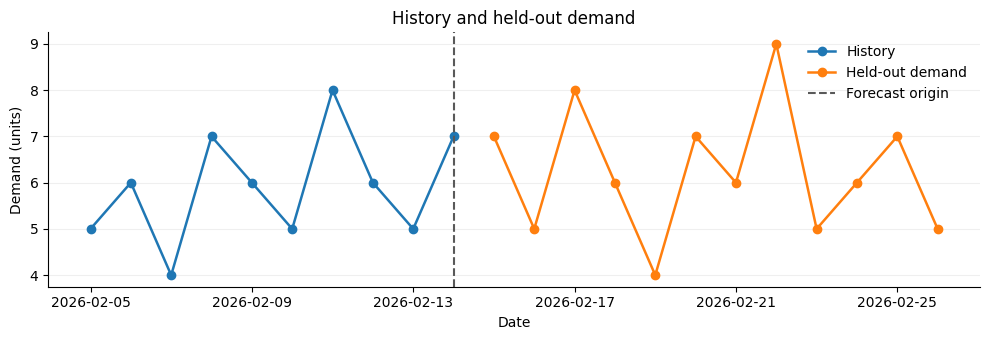

In [6]:
# Plot the data boundary before fitting the forecasting model.
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history['date'], history['y'], marker='o', linewidth=1.8, label='History')
ax.plot(holdout['date'], holdout['y'], marker='o', linewidth=1.8, label='Held-out demand')
ax.axvline(forecast_origin, color='0.35', linestyle='--', label='Forecast origin')
ax.set(title='History and held-out demand', xlabel='Date', ylabel='Demand (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 2. Fit once, then construct four ways

A single `ES(model='ANN')` fit supplies every method below. Its four daily means and 95% upper bounds are the shared input; the constructions differ only in how they turn those marginals — or bypass them — into one cumulative number.


In [7]:
# One univariate fit on the observed history; every method reuses this object.
model = ES(model='ANN')
model.fit(history['y'])

# Daily means and upper bounds stay separate here: they are marginals, not the target.
daily_forecast = model.predict(
    h=protection_horizon,
    interval='prediction',
    level=service_level,
    side='upper',
    cumulative=False,
)

forecast_dates = pd.date_range(
    forecast_origin + pd.Timedelta(days=1),
    periods=protection_horizon,
    freq=period_frequency,
)
daily_forecast_output = pd.DataFrame({
    'date': forecast_dates,
    'forecast_mean': daily_forecast.mean.to_numpy(),
    'daily_upper_95': daily_forecast.upper.iloc[:, 0].to_numpy(),
    'heldout_demand': holdout.loc[:protection_horizon - 1, 'y'].to_numpy(),
})


In [8]:
# Four daily means with separate upper bounds, beside demand later observed.
daily_forecast_output.round(3)


,date,forecast_mean,daily_upper_95,heldout_demand
0,2026-02-15,5.9,7.869,7.0
1,2026-02-16,5.9,7.869,5.0
2,2026-02-17,5.9,7.869,8.0
3,2026-02-18,5.9,7.869,6.0


### Method A: sum the daily upper bounds (the wrong baseline)

Adding the four 95% daily bounds treats four separate per-day promises as one total promise. Because a high Monday can offset a low Tuesday, the true 95% bound on the total is lower — this sum overstates it. It is included so the replay can price the overstatement.


In [9]:
# Naive construction: one number per day added into a total.
summed_target = float(daily_forecast_output['daily_upper_95'].sum())
print(f'Summed marginal 95% bounds: {summed_target:.3f}')


Summed marginal 95% bounds: 31.477


### Method B: independent-normal aggregation inside Pyforia

Back out one per-day standard deviation from each marginal bound under normality, `sigma = (q95 - mean) / z`, and let the policy aggregate analytically as `S = sum(mean) + z * sqrt(sum(sigma^2))`. Variances add where quantiles do not. This assumes independent Gaussian days — stated on the fitted policy as `independent_normal_marginals`, not as observed truth.


In [10]:
# z converts each upper bound back into the sigma it implies under normality.
z = NormalDist().inv_cdf(service_level)
marginal_inputs = pd.DataFrame({
    'unique_id': [sku] * protection_horizon,
    'fh': range(1, protection_horizon + 1),
    'date': forecast_dates,
    'mean': daily_forecast_output['forecast_mean'].to_numpy(),
    'std': ((daily_forecast_output['daily_upper_95'] - daily_forecast_output['forecast_mean']) / z).to_numpy(),
})
policy_independent = OrderUpToPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=service_level,
    allow_backorders=False,
).fit(
    marginal_inputs,
    mean_column='mean',
    std_column='std',
    target_probability=service_level,
    protection_horizon=protection_horizon,
    aggregation_method='independent_normal',
    forecast_origin=forecast_origin,
    forecast_frequency=period_frequency,
    forecast_date_column='date',
)

print('Independent-normal inputs')
print(marginal_inputs.round(3).to_string(index=False))
print('\nFitted target')
print(policy_independent.get_target_levels().round(3).to_string(index=False))
print('\nTarget metadata')
print(pd.DataFrame([policy_independent.get_target_metadata()]).to_string(index=False))


Independent-normal inputs
unique_id  fh       date  mean   std
 tea_250g   1 2026-02-15   5.9 1.197
 tea_250g   2 2026-02-16   5.9 1.197
 tea_250g   3 2026-02-17   5.9 1.197
 tea_250g   4 2026-02-18   5.9 1.197

Fitted target
unique_id  target_level
 tea_250g        27.539

Target metadata
              representation  target_probability  protection_horizon        target_source     forecast_origin forecast_frequency     target_end_date calculation_method
independent_normal_marginals                0.95                   4 built_in_calculation 2026-02-14T00:00:00                  D 2026-02-18T00:00:00 independent_normal


### Methods C and D: ask Smooth for the total directly

`cumulative=True` never forms marginals: `approximate` maps the model's full four-day error covariance onto the total, and `simulated` sums thousands of joint demand paths and reads the quantile. Agreement between the two is itself a check on the machinery.


In [11]:
# Two calls, same question: the 95% upper bound of the four-day total.
cumulative_approx = model.predict(
    h=protection_horizon,
    interval='approximate',
    level=service_level,
    side='upper',
    cumulative=True,
)
cumulative_sim = model.predict(
    h=protection_horizon,
    interval='simulated',
    level=service_level,
    side='upper',
    cumulative=True,
    nsim=5000,
)
approx_target = float(cumulative_approx.upper.iloc[-1, 0])
sim_target = float(cumulative_sim.upper.iloc[-1, 0])
cumulative_mean = float(cumulative_approx.mean.iloc[-1])
print(f'Direct approximate upper 95%: {approx_target:.3f}')
print(f'Simulated upper 95% (5000 paths): {sim_target:.3f}')

# The simulated quantile is sampling noise around the approximate one, inside a wide band.
assert cumulative_mean < sim_target < summed_target
assert abs(sim_target - approx_target) < 1.5


Direct approximate upper 95%: 27.539
Simulated upper 95% (5000 paths): 27.786


## 3. Compare the four targets on one scale

Same forecast, same horizon, same probability — the spread below is pure construction effect. The dashed line is the realized four-day total (26.0 units): every construction covers it here, so the replay question becomes what the extra units cost in stock, not whether service survives.


In [12]:
indep_target = float(policy_independent.get_target_levels().loc[0, 'target_level'])
comparison_targets = pd.DataFrame([
    {'method': 'A: summed marginal bounds', 'protection_target': summed_target,
     'construction': 'sum of four daily 95% bounds'},
    {'method': 'B: independent-normal', 'protection_target': indep_target,
     'construction': 'sum(mean) + z * sqrt(sum(sigma^2))'},
    {'method': 'C: direct approximate', 'protection_target': approx_target,
     'construction': "model covariance of the total"},
    {'method': 'D: simulated (5000 paths)', 'protection_target': sim_target,
     'construction': 'quantile of summed joint paths'},
])
realized_total = float(holdout.loc[:protection_horizon - 1, 'y'].sum())

# The naive sum is the most conservative; independence and joint machinery agree here.
assert summed_target > approx_target
assert abs(indep_target - approx_target) < 0.05
assert (comparison_targets['protection_target'] > realized_total).all()

comparison_targets.round(3)


,method,protection_target,construction
0,A: summed marginal bounds,31.477,sum of four daily 95% bounds
1,B: independent-normal,27.539,sum(mean) + z * sqrt(sum(sigma^2))
2,C: direct approximate,27.539,model covariance of the total
3,D: simulated (5000 paths),27.786,quantile of summed joint paths


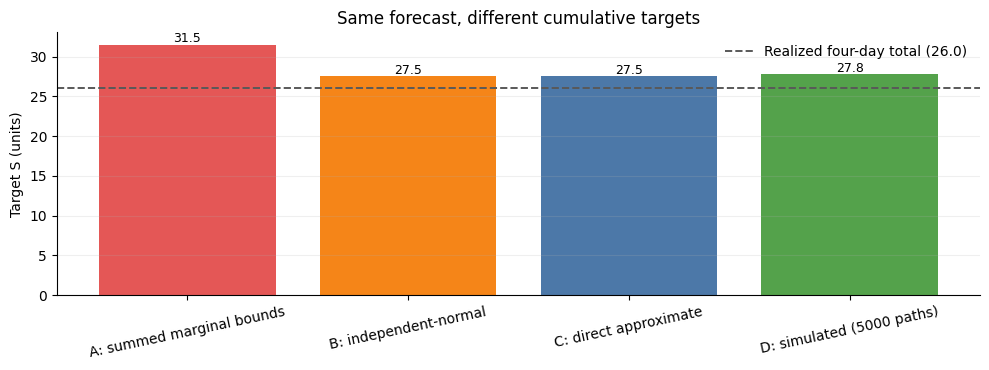

In [13]:
# Bars suit a categorical comparison; the line marks demand later observed.
fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.bar(
    comparison_targets['method'], comparison_targets['protection_target'],
    color=['#E45756', '#F58518', '#4C78A8', '#54A24B'],
)
ax.axhline(realized_total, color='0.35', linestyle='--', linewidth=1.4,
           label=f'Realized four-day total ({realized_total:.1f})')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
ax.set(title='Same forecast, different cumulative targets', ylabel='Target S (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=12)
fig.tight_layout()
plt.show()


## 4. Replay every construction on the same demand

Each target becomes one fitted `(R, S)` policy — same class, lead time, review period, and service level — and `run_comparison` replays all four on the identical twelve-day holdout with the same opening stock, timing, and windows. Any gap in the metrics below comes from the target construction alone.


In [14]:
# The naive sum is still an externally calculated total, so it takes the direct route.
def direct_policy(target_value):
    frame = pd.DataFrame({
        'unique_id': [sku],
        'protection_target': [target_value],
        'target_end_date': [forecast_dates[-1]],
    })
    return OrderUpToPolicy(
        lead_time=lead_time,
        review_period=review_period,
        service_level=service_level,
        allow_backorders=False,
    ).fit(
        frame,
        target_column='protection_target',
        target_probability=service_level,
        protection_horizon=protection_horizon,
        target_source='external_direct',
        forecast_origin=forecast_origin,
        forecast_frequency=period_frequency,
        target_end_date_column='target_end_date',
    )

policy_summed = direct_policy(summed_target)
policy_approx = direct_policy(approx_target)
policy_simulated = direct_policy(sim_target)

fitted_levels = pd.DataFrame([
    {'method': 'A: summed marginal bounds',
     'target_level': float(policy_summed.get_target_levels().loc[0, 'target_level'])},
    {'method': 'B: independent-normal',
     'target_level': float(policy_independent.get_target_levels().loc[0, 'target_level'])},
    {'method': 'C: direct approximate',
     'target_level': float(policy_approx.get_target_levels().loc[0, 'target_level'])},
    {'method': 'D: simulated (5000 paths)',
     'target_level': float(policy_simulated.get_target_levels().loc[0, 'target_level'])},
])
print('Fitted target levels entering the replay')
print(fitted_levels.round(3).to_string(index=False))


Fitted target levels entering the replay
                   method  target_level
A: summed marginal bounds        31.477
    B: independent-normal        27.539
    C: direct approximate        27.539
D: simulated (5000 paths)        27.786


In [15]:
# Opening stock is a declared inventory input, independent of the forecast.
opening_stock = pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [12.0]})
opening_stock


,unique_id,observed_on_hand
0,tea_250g,12.0


In [16]:
# The engine deep-copies this state per branch; the caller-owned object is preserved.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=12, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [17]:
# Four branches, one shared demand calendar and timing contract.
comparison = SimulationEngine().run_comparison(
    policies=[policy_summed, policy_independent, policy_approx, policy_simulated],
    labels=[
        'A: summed marginals',
        'B: independent-normal',
        'C: direct approximate',
        'D: simulated',
    ],
    demand_source=holdout,
    inventory=opening_inventory,
    n_periods=len(holdout),
    period_frequency=period_frequency,
    # Place the first policy order before the first held-out demand arrives.
    initial_decision='before_first_demand',
    # Every day advances inventory, but only the middle eight days are scored.
    warmup_periods=2,
    scoring_periods=8,
    settlement_periods=2,
    order_during_settlement=False,
    demand_source_name='declared_heldout_tea_demand',
    random_seed=None,
)

print('Scoring summaries by construction')
for label, branch in comparison.results.items():
    print(f'\n{label}')
    print(pd.DataFrame([branch.summary()]).round(3).to_string(index=False))


Scoring summaries by construction

A: summed marginals
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                              15.727                 0               51.0                  4                     4

B: independent-normal
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                              11.789                 0               51.0                  4                     4

C: direct approximate
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                              11.789                 0               51.0                 

## 5. Read what the constructions cost

One evaluation contract — same scoring window, same pooled metrics — applied to every branch. These are units and service measures on declared synthetic demand, so no cost rate or operational claim follows.


In [18]:
# InventoryEvaluator reads validated scoring events from each branch.
metric_rows = []
for label, branch in comparison.results.items():
    row = InventoryEvaluator().fit(
        branch, window='scoring',
    ).evaluate(
        metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
        groupby=[],
    ).iloc[0].to_dict()
    row['method'] = label
    metric_rows.append(row)
metrics_table = pd.DataFrame(metric_rows).set_index('method')
print(metrics_table.round(3).to_string())


                       fill_rate  demand_period_service_level  avg_on_hand  order_units
method                                                                                 
A: summed marginals          1.0                          1.0       15.727         51.0
B: independent-normal        1.0                          1.0       11.789         51.0
C: direct approximate        1.0                          1.0       11.789         51.0
D: simulated                 1.0                          1.0       12.036         51.0


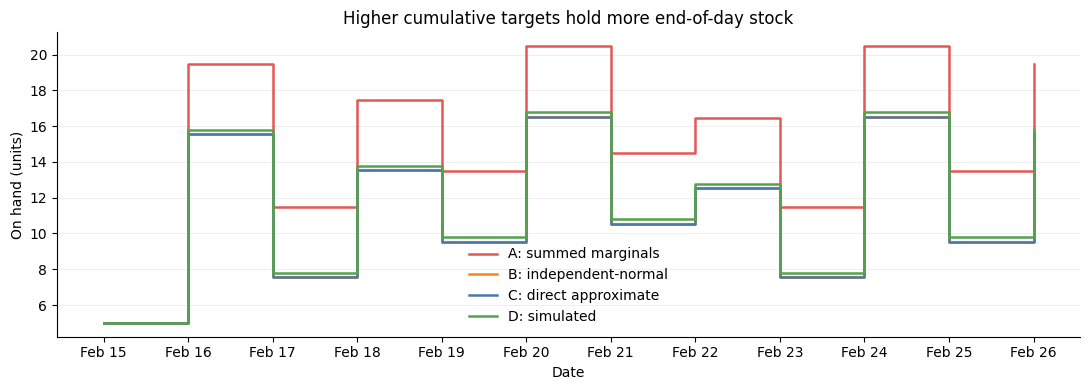

In [19]:
# Step lines show end-of-day stock: receipts arrive first, then demand is served.
fig, ax = plt.subplots(figsize=(11, 4))
branch_colors = {
    'A: summed marginals': '#E45756',
    'B: independent-normal': '#F58518',
    'C: direct approximate': '#4C78A8',
    'D: simulated': '#54A24B',
}
for label, branch in comparison.results.items():
    branch_periods = branch.to_event_frame(window='all')
    branch_periods = branch_periods.loc[branch_periods['event_type'].eq('period')]
    ax.step(branch_periods['date'], branch_periods['ending_on_hand'], where='post',
            color=branch_colors[label], linewidth=1.8, label=label)
ax.set(title='Higher cumulative targets hold more end-of-day stock', xlabel='Date', ylabel='On hand (units)')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## Takeaway

The forecast never changed, yet the summed bounds asked for about four units more than the joint constructions — pure construction effect, visible before any simulation. The replay then prices it: identical service on this holdout, paid for in higher average stock. Use a direct cumulative bound (or the independent-normal route when its assumption is stated) and never a sum of marginal quantiles.
